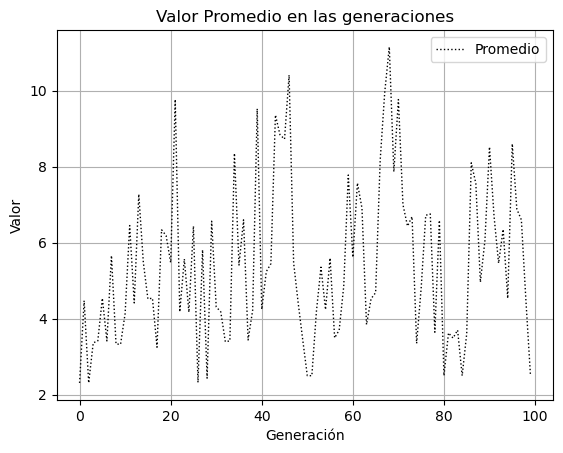

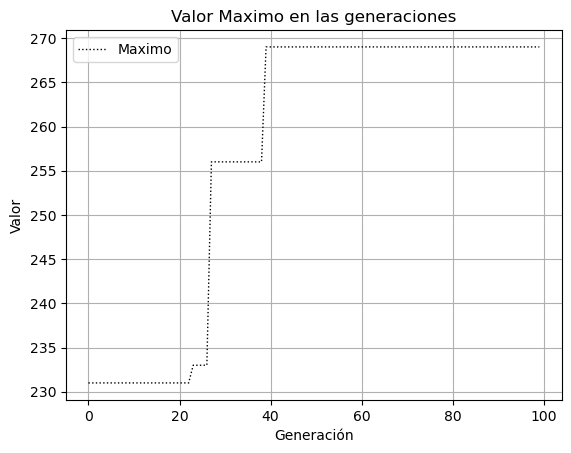

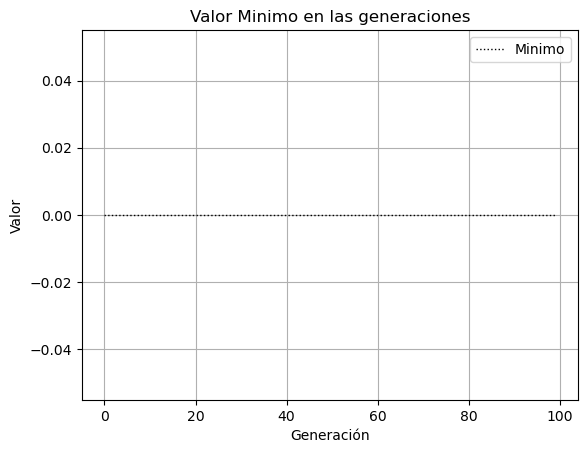

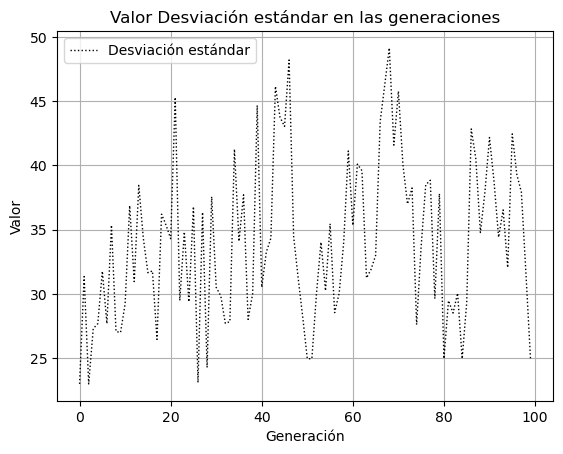

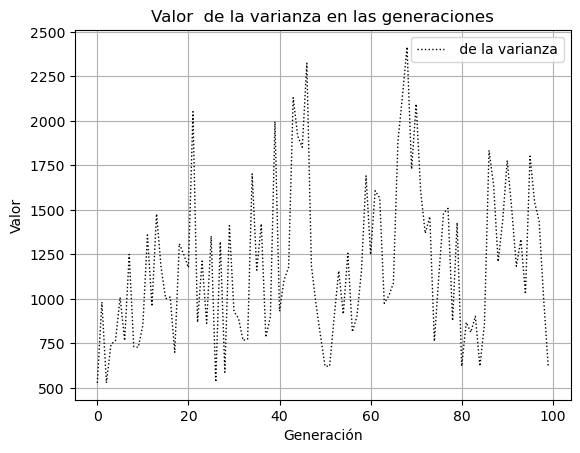

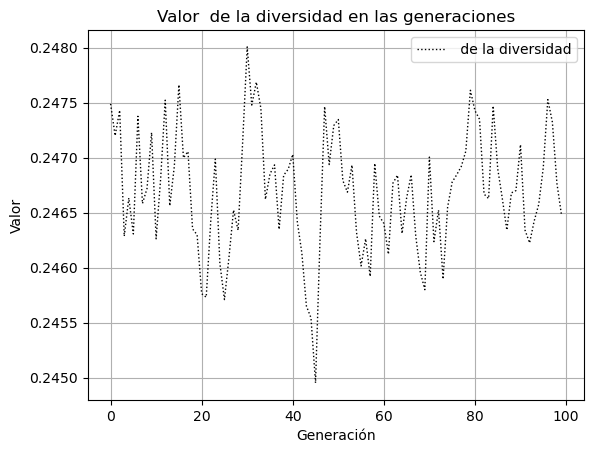

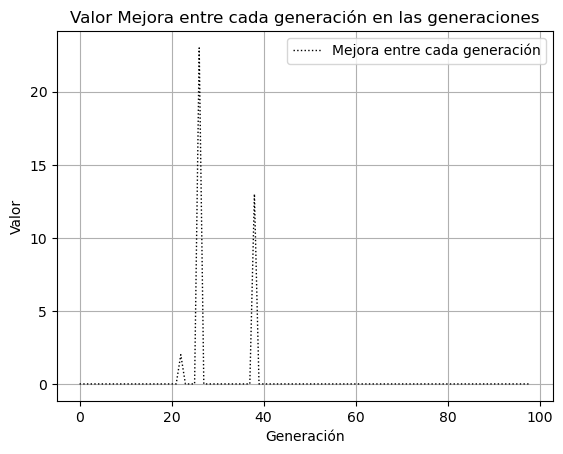

In [ ]:
from supervivencia import Con_elitismo, Sin_elitismo, Supervivencia
from penalizacion import Penalizacion, Lineal, Fitness_Cero, Cuadratica, Exponencial
from carga import Carga
from grafica import Grafica, Grafica_lineas
from fitness import Fitness
import numpy as np
import numpy.typing as npt
from mutacion import Mutacion, Seleccion_aleatoria, Tasa_mutacion
from cruze import Cruce_cargas, Cruce_uniforme, Cruce_un_punto, Cruce_dos_punto
from contenedor import Contenedor
from diversidad import Diversidad


# Configuración
tamano_poblacion: int = 100
max_generaciones: int = 100

# Métricas por generación
valor_minimo_generacion: list[int] = []
valor_maximo_generacion: list[int] = []
valor_promedio_generacion: list[float] = []
valor_desviacion_std_generacion: list[float] = []
valor_varianza_generacion: list[float] = []
valor_diversidad_generacion: list[float] = []

# Inicialización
carga = Carga()
cargas: list[npt.NDArray[np.int32]] = carga.generar_carga()


poblacion: list[Contenedor] = []
mejor_generacion_anterior: Contenedor = None
# Llevamos la carga de los contenedores
for carga in cargas:
    contenedor = Contenedor(carga=carga)
    poblacion.append(contenedor)


supervivencia: Supervivencia = Con_elitismo()
fitness: Fitness 
diversidad: Diversidad = Diversidad()
poblacion: list[Contenedor] = []

# Opciones de calculo del fitnes para la penalización.
# - fitnes_cero
# - lineal
# - cuadratica
# - exponencial

metodo_penalizacion: str = "fitnes_cero" 

# opciones para la Mutación y la recombinacion (Cruza)
# recombinacion (Cruce_cargas)
#  -  
# mutacion (Mutacion)
#  - 

recombinacion:Cruce_cargas = Cruce_dos_punto
mutacion:Mutacion = Seleccion_aleatoria

# Evolución
for generacion in range(max_generaciones):
    
    aptitudes:list[int] = []

    # Llevamos la carga a los contenedores
    for carga in cargas:
        contenedor = Contenedor(carga=carga)
        poblacion.append(contenedor)

    # Calculamos su fitnes
    for contenedor in poblacion:
        fitness = Fitness(carga=contenedor.carga)
        aptitudes.append(fitness.calcular_fitness(penalizacion_selecionada=metodo_penalizacion))
    
    # Llevamos su fitnes al contenedor    
    for posicion, fitness in enumerate(aptitudes):
        poblacion[posicion].fitness = fitness

    if not mejor_generacion_anterior == None:
        posicion, carga_minima = min(enumerate(poblacion),
                                        key=lambda x: x[1].fitness)
        
        poblacion[posicion] = mejor_generacion_anterior

    # Esto se debe sacar de los objetos
    aptitudes = []
    for aptitud in poblacion:
        aptitudes.append(aptitud.fitness)

    valor_maximo:int = (np.max(aptitudes))
    valor_minimo:int = (np.min(aptitudes))
    valor_promedio: float = (np.mean(aptitudes))
    valor_desviacion_std: float = (np.std(aptitudes))
    valor_varianza: float = (np.var(aptitudes))
    valor_divercidad:float = diversidad.calcular_diversidad(poblacion=poblacion)

    nueva_generacion,mejor_generacion_anterior = supervivencia.seleccion_supervivencia( poblacion=poblacion,
                                                                        tamano_poblacion=tamano_poblacion,
                                                                        generacion=generacion,
                                                                        max_generaciones=max_generaciones,
                                                                        mutacion=mutacion,
                                                                        recombinacion=recombinacion, 
                                                                    )

    valor_maximo_generacion.append(valor_maximo)
    valor_minimo_generacion.append(valor_minimo)
    valor_promedio_generacion.append(valor_promedio)
    valor_desviacion_std_generacion.append(valor_desviacion_std)
    valor_varianza_generacion.append(valor_varianza)
    valor_diversidad_generacion.append(valor_divercidad)

    
    poblacion = nueva_generacion


grafica_promedio: Grafica = Grafica_lineas()
grafica_maximo: Grafica = Grafica_lineas()
grafica_minimo: Grafica = Grafica_lineas()
grafica_desviacion_std: Grafica = Grafica_lineas()
grafica_mejora_generacion: Grafica = Grafica_lineas()
grafica_varianza: Grafica = Grafica_lineas()
grafica_diversidad: Grafica = Grafica_lineas()
grafica_diversidad_vs_fitness = Grafica_lineas()

grafica_promedio.generar_grafica(datos=valor_promedio_generacion,etiqueta="Promedio")
grafica_maximo.generar_grafica(datos=valor_maximo_generacion,etiqueta="Maximo")
grafica_minimo.generar_grafica(datos=valor_minimo_generacion,etiqueta="Minimo")
grafica_desviacion_std.generar_grafica(datos=valor_desviacion_std_generacion,etiqueta="Desviación estándar")
grafica_varianza.generar_grafica(datos=valor_varianza_generacion,etiqueta=" de la varianza")
grafica_diversidad.generar_grafica(datos=valor_diversidad_generacion,etiqueta=" de la diversidad")
grafica_diversidad_vs_fitness.generar_grafica(datos=(valor_diversidad_generacion,valor_maximo_generacion),
                                              etiqueta="Fitness minimo vs Diversidad")

mejora = np.diff(valor_maximo_generacion)
grafica_mejora_generacion.generar_grafica(datos=mejora,etiqueta="Mejora entre cada generación")
